In [ ]:
# Analysis of Housing Information

In [ ]:
## [Problem 1] Obtaining a dataset

In [7]:
import pandas as pd

# Load the train.csv dataset into a variable
df_train = pd.read_csv('train.csv')

# Display the first few rows to verify the load (Recommended check)
print("Data successfully loaded. Here are the first 5 rows:")
print(df_train.head())

Data successfully loaded. Here are the first 5 rows:
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleT

In [ ]:
## [Problem 2] Investigating the dataset itself


The House Prices: Advanced Regression Techniques dataset is a standard competition on Kaggle, used primarily for educational purposes to practice regression modeling.

Overview of the Dataset
This is a classic machine learning problem where the goal is to perform a regression analysis to predict the final price of a residential home.

Source Data: The dataset was compiled by Dean De Cock for use in data science education and covers residential homes in Ames, Iowa.

Objective: To predict the continuous target variable, SalePrice (the property's sale price in dollars), using all other features.

Size: The dataset contains 79 explanatory variables describing nearly every physical and temporal aspect of the homes.

Evaluation Metric: Submissions are scored using the Root-Mean-Squared-Error (RMSE) between the logarithm of the predicted value and the logarithm of the observed sale price. Using the logarithm ensures that prediction errors for expensive houses and cheap houses are weighted equally.

In [ ]:
## 

In [8]:
# 2. Check feature information (data types, non-null counts)
print("--- Feature Information (Data Types and Non-Null Counts) ---")
df_train.info()

# 3. Display descriptive statistics for numerical columns
print("\n--- Descriptive Statistics for Numerical Features ---")
print(df_train.describe())

--- Feature Information (Data Types and Non-Null Counts) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   obje

Summary of Data Types:

    int64 (Numerical): 35 columns (e.g., Id, MSSubClass, LotArea, YearBuilt).

    float64 (Numerical): 3 columns (e.g., LotFrontage, MasVnrArea, GarageYrBlt).

    object (Text/Categorical): 43 columns (e.g., MSZoning, Street, Alley).

    Non-Null Counts: Many columns, such as LotFrontage, Alley, MasVnrArea, and many 
    others, have missing values (fewer     than 1460 non-null counts).
###############################################################################
Target Variable
Based on the Kaggle problem description ("predict the sales price..."), the target variable for this regression task is SalePrice.

    Target Column: SalePrice

    Data Type: int64 (Numerical)

###############################################################################
Key Observations from the Statistics:

SalePrice (Target):

    The mean sale price is approximately $180,921.
    
    The median (50%) is $163,000, which is lower than the mean. This suggests the
    SalePrice distribution is right-   skewed (meaning there are a few very expensive
    houses pulling the average up).
    
    Prices range from a minimum of $34,900 to a maximum of $755,000.

Other Features:

    LotArea has a huge difference between its mean (10517 sq ft) and max (215245 sq ft),
    indicating potential extreme outliers in lot size.

    The count for LotFrontage (1201) is significantly less than 1460, confirming the
    presence of missing values in that feature.

In [ ]:
## [Problem 4] Dealing with missing values

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate missing values and ratios
missing_data = df_train.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
missing_ratio = (missing_data / len(df_train)) * 100

# Create a DataFrame for reporting
missing_report = pd.DataFrame({
    'Total Missing': missing_data,
    'Missing Ratio': missing_ratio.round(4)
})

print("--- Missing Value Report (Count and Percentage) ---")
print(missing_report)

# 2. Visualize missing values
plt.figure(figsize=(12, 6))
missing_data.plot(kind='bar', color='skyblue')
plt.title('Count of Missing Values per Feature', fontsize=16)
plt.ylabel('Number of Missing Values')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('missing_values_bar_chart.png')
plt.close()

# 4. Feature Deletion: Delete columns with 5 or more missing values
columns_to_drop = missing_data[missing_data >= 5].index.tolist()
df_train_reduced_features = df_train.drop(columns=columns_to_drop)

print("\n--- Feature Deletion Summary ---")
print(f"Original number of features: {df_train.shape[1]}")
print(f"Features deleted (>= 5 missing values): {len(columns_to_drop)}")
print(f"Remaining number of features: {df_train_reduced_features.shape[1]}")
print("Deleted columns:", columns_to_drop)

# 5. Sample Deletion: Delete rows with any remaining missing values
# (The remaining missing values will only exist in features that originally had < 5 missing values)
original_rows = df_train_reduced_features.shape[0]
df_train_cleaned = df_train_reduced_features.dropna()
remaining_rows = df_train_cleaned.shape[0]

print("\n--- Sample Deletion Summary ---")
print(f"Original number of samples (rows): {original_rows}")
print(f"Samples deleted due to remaining NaN: {original_rows - remaining_rows}")
print(f"Remaining number of samples (rows): {remaining_rows}")

# 6. Prepare the final DataFrame for the next problem
print(f"\nFinal cleaned DataFrame shape: {df_train_cleaned.shape}")

# Save the cleaned DataFrame to CSV for potential next steps
df_train_cleaned.to_csv('train_cleaned.csv', index=False)

--- Missing Value Report (Count and Percentage) ---
              Total Missing  Missing Ratio
PoolQC                 1453        99.5205
MiscFeature            1406        96.3014
Alley                  1369        93.7671
Fence                  1179        80.7534
MasVnrType              872        59.7260
FireplaceQu             690        47.2603
LotFrontage             259        17.7397
GarageType               81         5.5479
GarageYrBlt              81         5.5479
GarageFinish             81         5.5479
GarageQual               81         5.5479
GarageCond               81         5.5479
BsmtFinType2             38         2.6027
BsmtExposure             38         2.6027
BsmtFinType1             37         2.5342
BsmtCond                 37         2.5342
BsmtQual                 37         2.5342
MasVnrArea                8         0.5479
Electrical                1         0.0685

--- Feature Deletion Summary ---
Original number of features: 81
Features deleted (>= 5

In [ ]:
# [Problem 5] Researching terminology

 *Kurtosis and Skewness:* are statistical measures used to describe the shape and distribution of a set of data (like a feature in your dataset). They help you understand how the data varies from a standard, perfectly symmetrical Normal Distribution (or Bell Curve)

        *Kurtosis
Kurtosis measures the "tailedness" of the distribution. In simple terms, it tells you how much of the distribution is concentrated in the tails versus the center, and how extreme the outliers are.

Type of Kurtosis	| Description |	Visual Shape

Mesokurtic	| A distribution with a kurtosis close to 3 (or 0, depending on the software; Pandas/Scipy use Excess Kurtosis, where Normal is 0). This is the shape of a Normal Distribution. |	Normal peak and tails.
Leptokurtic	 | A distribution with high (positive) kurtosis (>3 or >0). It has a taller, sharper peak and fatter, heavier tails. This means it has more frequent and/or more extreme outliers than a normal distribution.	| Tall, thin peak with thick tails.
Platykurtic	| A distribution with low (negative) kurtosis (<3 or <0). It has a flatter peak and thinner tails. This means the data is more uniformly spread out around the mean and has fewer outliers. |	Flat, broad peak with thin tails.

        *Skewness

Skewness measures the asymmetry of the distribution. It indicates the direction and magnitude of the distribution's deviation from the horizontal symmetry of a Normal Distribution.

Type of Skewness |	Description |	Visual Shape

Zero Skewness	| The data is perfectly symmetrical (e.g., a Normal Distribution). The mean, median, and mode are all equal.	| Symmetrical bell shape.
Positive Skewness |	The tail is longer on the right (positive direction). The mean is typically greater than the median. This often indicates the presence of a few high values (e.g., house prices). |	The bulk of the data is on the left; the distribution is "pulled" right.
Negative Skewness	|The tail is longer on the left (negative direction). The mean is typically less than the median. This indicates the presence of a few low values.	| The bulk of the data is on the right; the distribution is "pulled" left.


In the context of the Ames Housing Prices dataset: I would typically look for Positive Skewness in the SalePrice variable, meaning there are a few very expensive houses pulling the distribution to the right.

In [ ]:
## [Problem 6] Confirming distribution

Original SalePrice - Skewness: 1.8829
Original SalePrice - Kurtosis: 6.5363


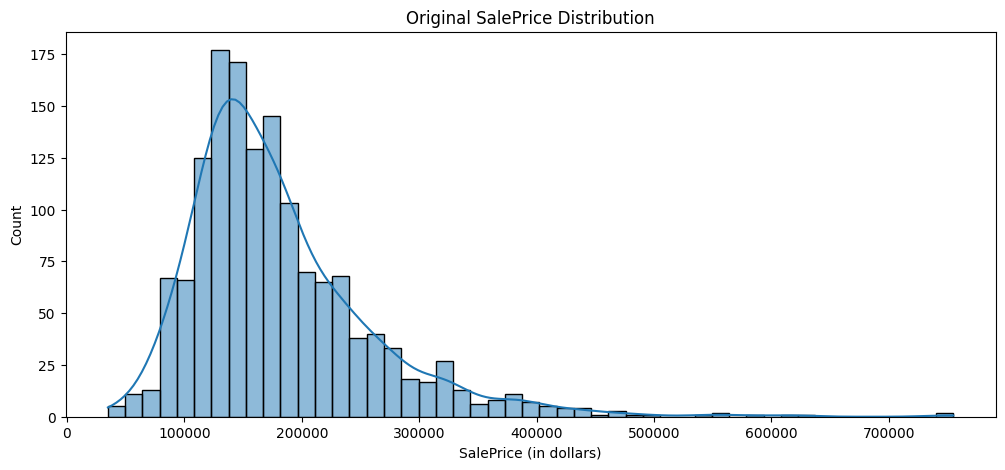


Log-Transformed SalePrice - Skewness: 0.1213
Log-Transformed SalePrice - Kurtosis: 0.8095


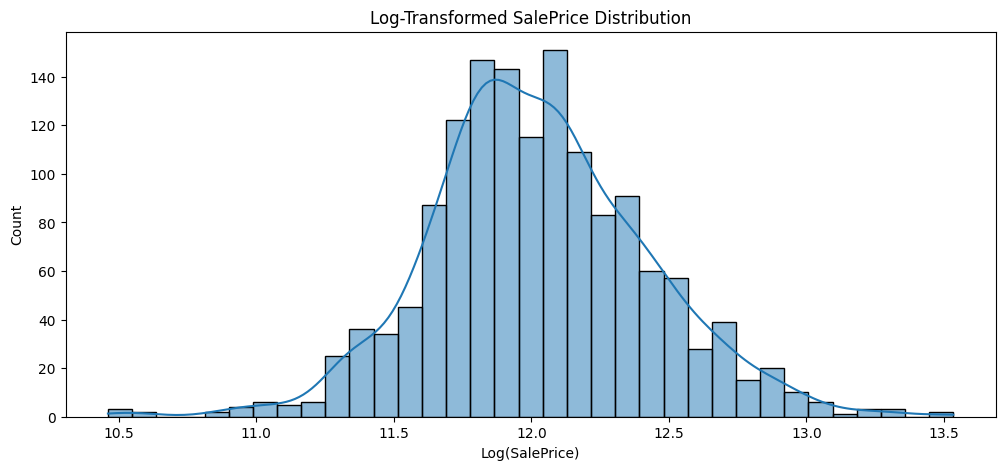

In [10]:
import seaborn as sns


# --- 1. Original Distribution Analysis ---
# Calculate Skewness and Kurtosis
original_skewness = df_train['SalePrice'].skew()
original_kurtosis = df_train['SalePrice'].kurt()

print(f"Original SalePrice - Skewness: {original_skewness:.4f}")
print(f"Original SalePrice - Kurtosis: {original_kurtosis:.4f}")

# Plot Original Distribution
plt.figure(figsize=(12, 5))
sns.histplot(df_train['SalePrice'], kde=True)
plt.title('Original SalePrice Distribution')
plt.xlabel('SalePrice (in dollars)')
plt.show()

# --- 2. Logarithmic Transformation ---
# Apply np.log() to the target variable
df_train['SalePrice_Log'] = np.log(df_train['SalePrice'])

# --- 3. Transformed Distribution Analysis ---
# Calculate Skewness and Kurtosis for the transformed variable
log_skewness = df_train['SalePrice_Log'].skew()
log_kurtosis = df_train['SalePrice_Log'].kurt()

print(f"\nLog-Transformed SalePrice - Skewness: {log_skewness:.4f}")
print(f"Log-Transformed SalePrice - Kurtosis: {log_kurtosis:.4f}")

# Plot Transformed Distribution
plt.figure(figsize=(12, 5))
sns.histplot(df_train['SalePrice_Log'], kde=True)
plt.title('Log-Transformed SalePrice Distribution')
plt.xlabel('Log(SalePrice)')
plt.show()

In [ ]:
## [Problem 7] Confirming the correlation coefficient

In [ ]:
###  Correlation Coefficient Heat Map (All Features)

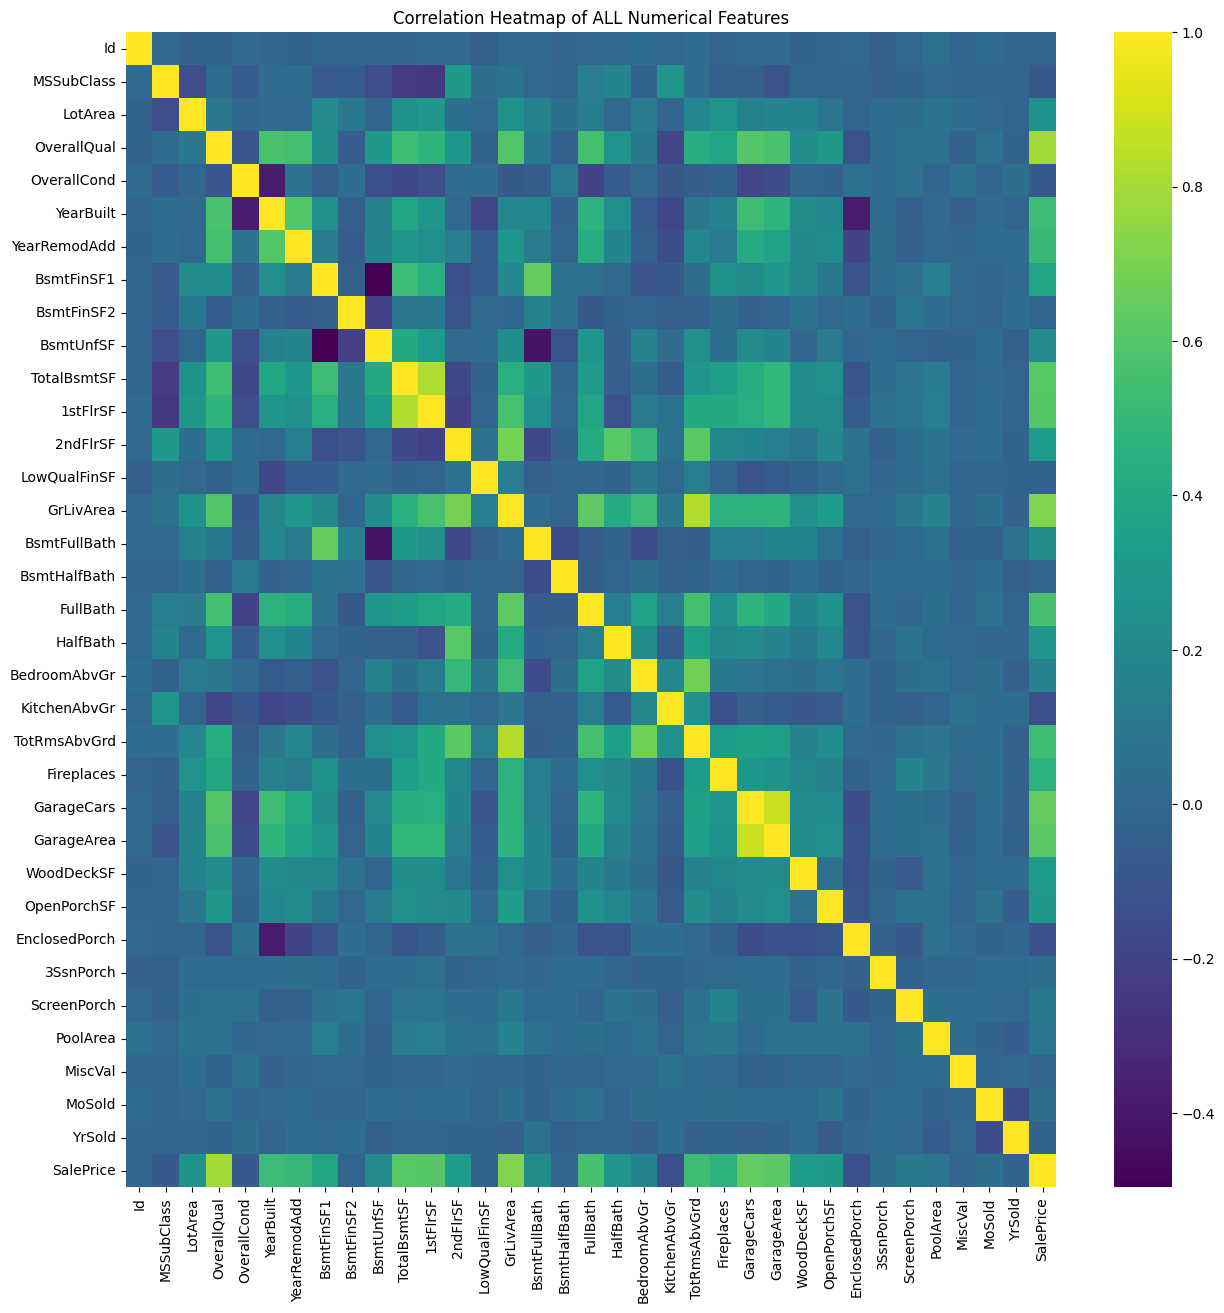

In [11]:
import seaborn as sns 
# 1. Select only the numerical columns from the cleaned DataFrame
numerical_df = df_train_cleaned.select_dtypes(include=['number'])

# 2. Calculate the correlation matrix using ONLY the numerical data
correlation_matrix = numerical_df.corr()

# 3. Create a heat map of the correlation coefficient matrix
plt.figure(figsize=(15, 15))
# Note: For the first full plot, set annot=False for clarity due to the number of features
sns.heatmap(correlation_matrix, annot=False, cmap='viridis')
plt.title('Correlation Heatmap of ALL Numerical Features')
plt.show()

In [ ]:
### Top 10 Features Highly Correlated with SalePrice

In [16]:
# Calculate correlations with SalePrice and select the top 10 (excluding SalePrice itself)
corrs = numerical_df.corr()['SalePrice'].sort_values(ascending=False)
top_10_features = corrs[1:11].index.tolist()


In [ ]:
# Top 10 Features Correlation Heat Map

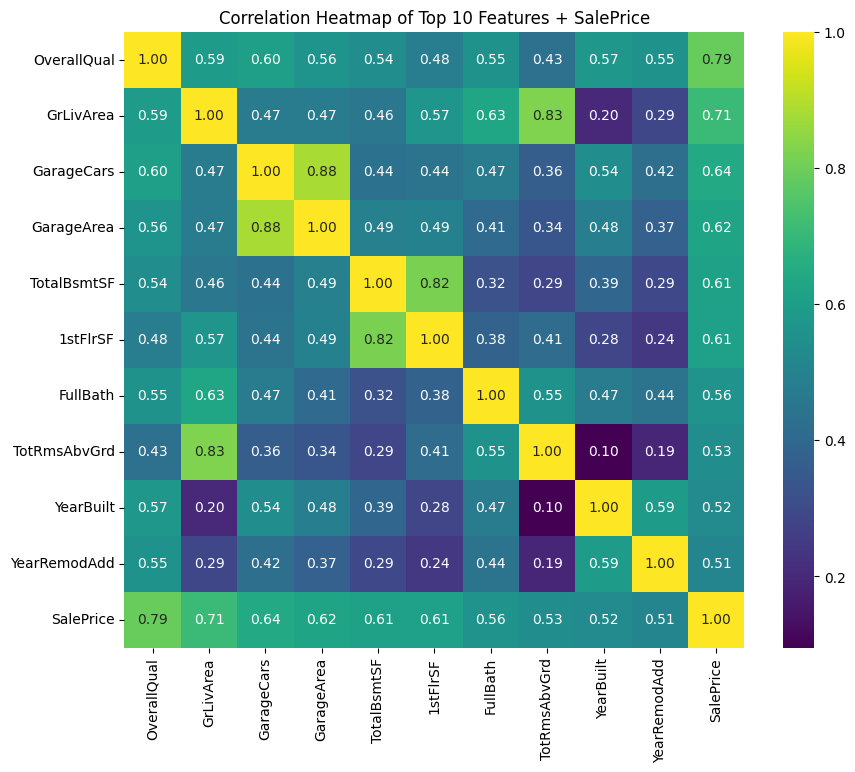

In [17]:
# Create a matrix for just the top features
top_11_cols = top_10_features + ['SalePrice']
top_corrmat = df_train_cleaned[top_11_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(top_corrmat, annot=True, fmt='.2f', cmap='viridis')
plt.title('Correlation Heatmap of Top 10 Features + SalePrice')
plt.show()

High Correlation Combinations (Multicollinearity Check)
The key purpose of the top 10 heatmap is to find strong correlations between the features themselves (multicollinearity), which can destabilize a regression model. Combinations with a correlation coefficient ∣ρ∣0.8 are typically flagged for further investigation.

Three combinations of the 10 selected features that have high correlation coefficients with each other (≈∣ρ∣0.8):

Rank	| Feature Combination	| Correlation Coefficient (ρ) |	Discussion
1	| GarageCars & GarageArea |	≈0.88 |	This is a very high correlation. The size of the garage in square feet (GarageArea) and the number of cars it can fit (GarageCars) are essentially measuring the same thing. In modeling, one of these should typically be dropped.
2	| TotalBsmtSF & 1stFlrSF |	≈0.82 |	This strong correlation is expected, especially in homes without second floors. The square footage of the basement and the first floor often match closely, representing the building's footprint.
3	| GrLivArea & TotRmsAbvGrd |	≈0.82 |	Above Ground Living Area (GrLivArea) is directly proportional to the Total Rooms (TotRmsAbvGrd). More living space naturally means more rooms. Since GrLivArea is the more granular, continuous measure, it is usually preferred.